# Insurance Customer Lifetime Value (CLV) & Policy Renewal Analytics
**Dataset:** IBM Watson Marketing Customer Value Data (`WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv`).
**Dimensi Data:** 9.134 profil nasabah asuransi kendaraan dengan 24 variabel demografis, premi, klaim, dan respons pembaruan polis (*Renew Offer Type*).

Notebook ini membangun sistem analitik nilai seumur hidup nasabah (*Customer Lifetime Value / CLV*) dan pemodelan retensi pembaruan polis. Tujuannya adalah mengestimasi nilai finansial jangka panjang nasabah serta mengidentifikasi penawaran renewal paling efektif untuk memaksimalkan retensi portofolio.

### Arsitektur Pipeline Analisis:
1. **Data Ingestion & Integrity Check**: Pemuatan 9.134 baris data nasabah, pembersihan format tanggal, dan standarisasi nama kolom.
2. **CLV & Retention Profiling (EDA)**: Analisis distribusi CLV, hubungan premi bulanan (`Monthly Premium Auto`), jumlah polis (`Number of Policies`), dan efektivitas jenis penawaran renewal (`Renew Offer Type`).
3. **Zero-Leakage Preprocessing & Pipeline**: Holdout Split terisolasi (80:20), log-transformasi target CLV kontinu, dan One-Hot Encoding fitur kategorikal.
4. **Predictive Modeling**: Perbandingan Baseline Linear (Ridge/Lasso), Random Forest Regressor, dan Gradient Boosting (LightGBM & XGBoost Regressor).
5. **Business & Financial Evaluation**: Evaluasi metrik $R^2$, RMSE, MAE, analisis *Feature Importance*, segmentasi kuadran nilai nasabah, dan ekspor grafik 300 DPI ke `images/`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

os.makedirs('images', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 15,
    'figure.figsize': (12, 6)
})

print("Konfigurasi pustaka dan visualisasi CLV berhasil diinisialisasi.")

Konfigurasi pustaka dan visualisasi CLV berhasil diinisialisasi.


In [2]:
df = pd.read_csv('data/WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv')

# Standarisasi format penamaan kolom
df.columns = [c.replace(' ', '_').lower() for c in df.columns]

print(f"Dimensi dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print("\nRingkasan Statistik Target Customer Lifetime Value:")
print(df['customer_lifetime_value'].describe())
df.head()

Dimensi dataset: 9,134 baris x 24 kolom



Ringkasan Statistik Target Customer Lifetime Value:
count     9134.000000
mean      8004.940475
std       6870.967608
min       1898.007675
25%       3994.251794
50%       5780.182197
75%       8962.167041
max      83325.381190
Name: customer_lifetime_value, dtype: float64


,customer,state,customer_lifetime_value,response,coverage,education,effective_to_date,employmentstatus,gender,income,...,months_since_policy_inception,number_of_open_complaints,number_of_policies,policy_type,policy,renew_offer_type,sales_channel,total_claim_amount,vehicle_class,vehicle_size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9100\1391298410.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=renewal_resp, x='renew_offer_type', y='response', palette='Blues_r', ax=axes[1, 0])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9100\1391298410.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='coverage', y='customer_lifetime_value', palette='Set2', ax=axes[1, 1])


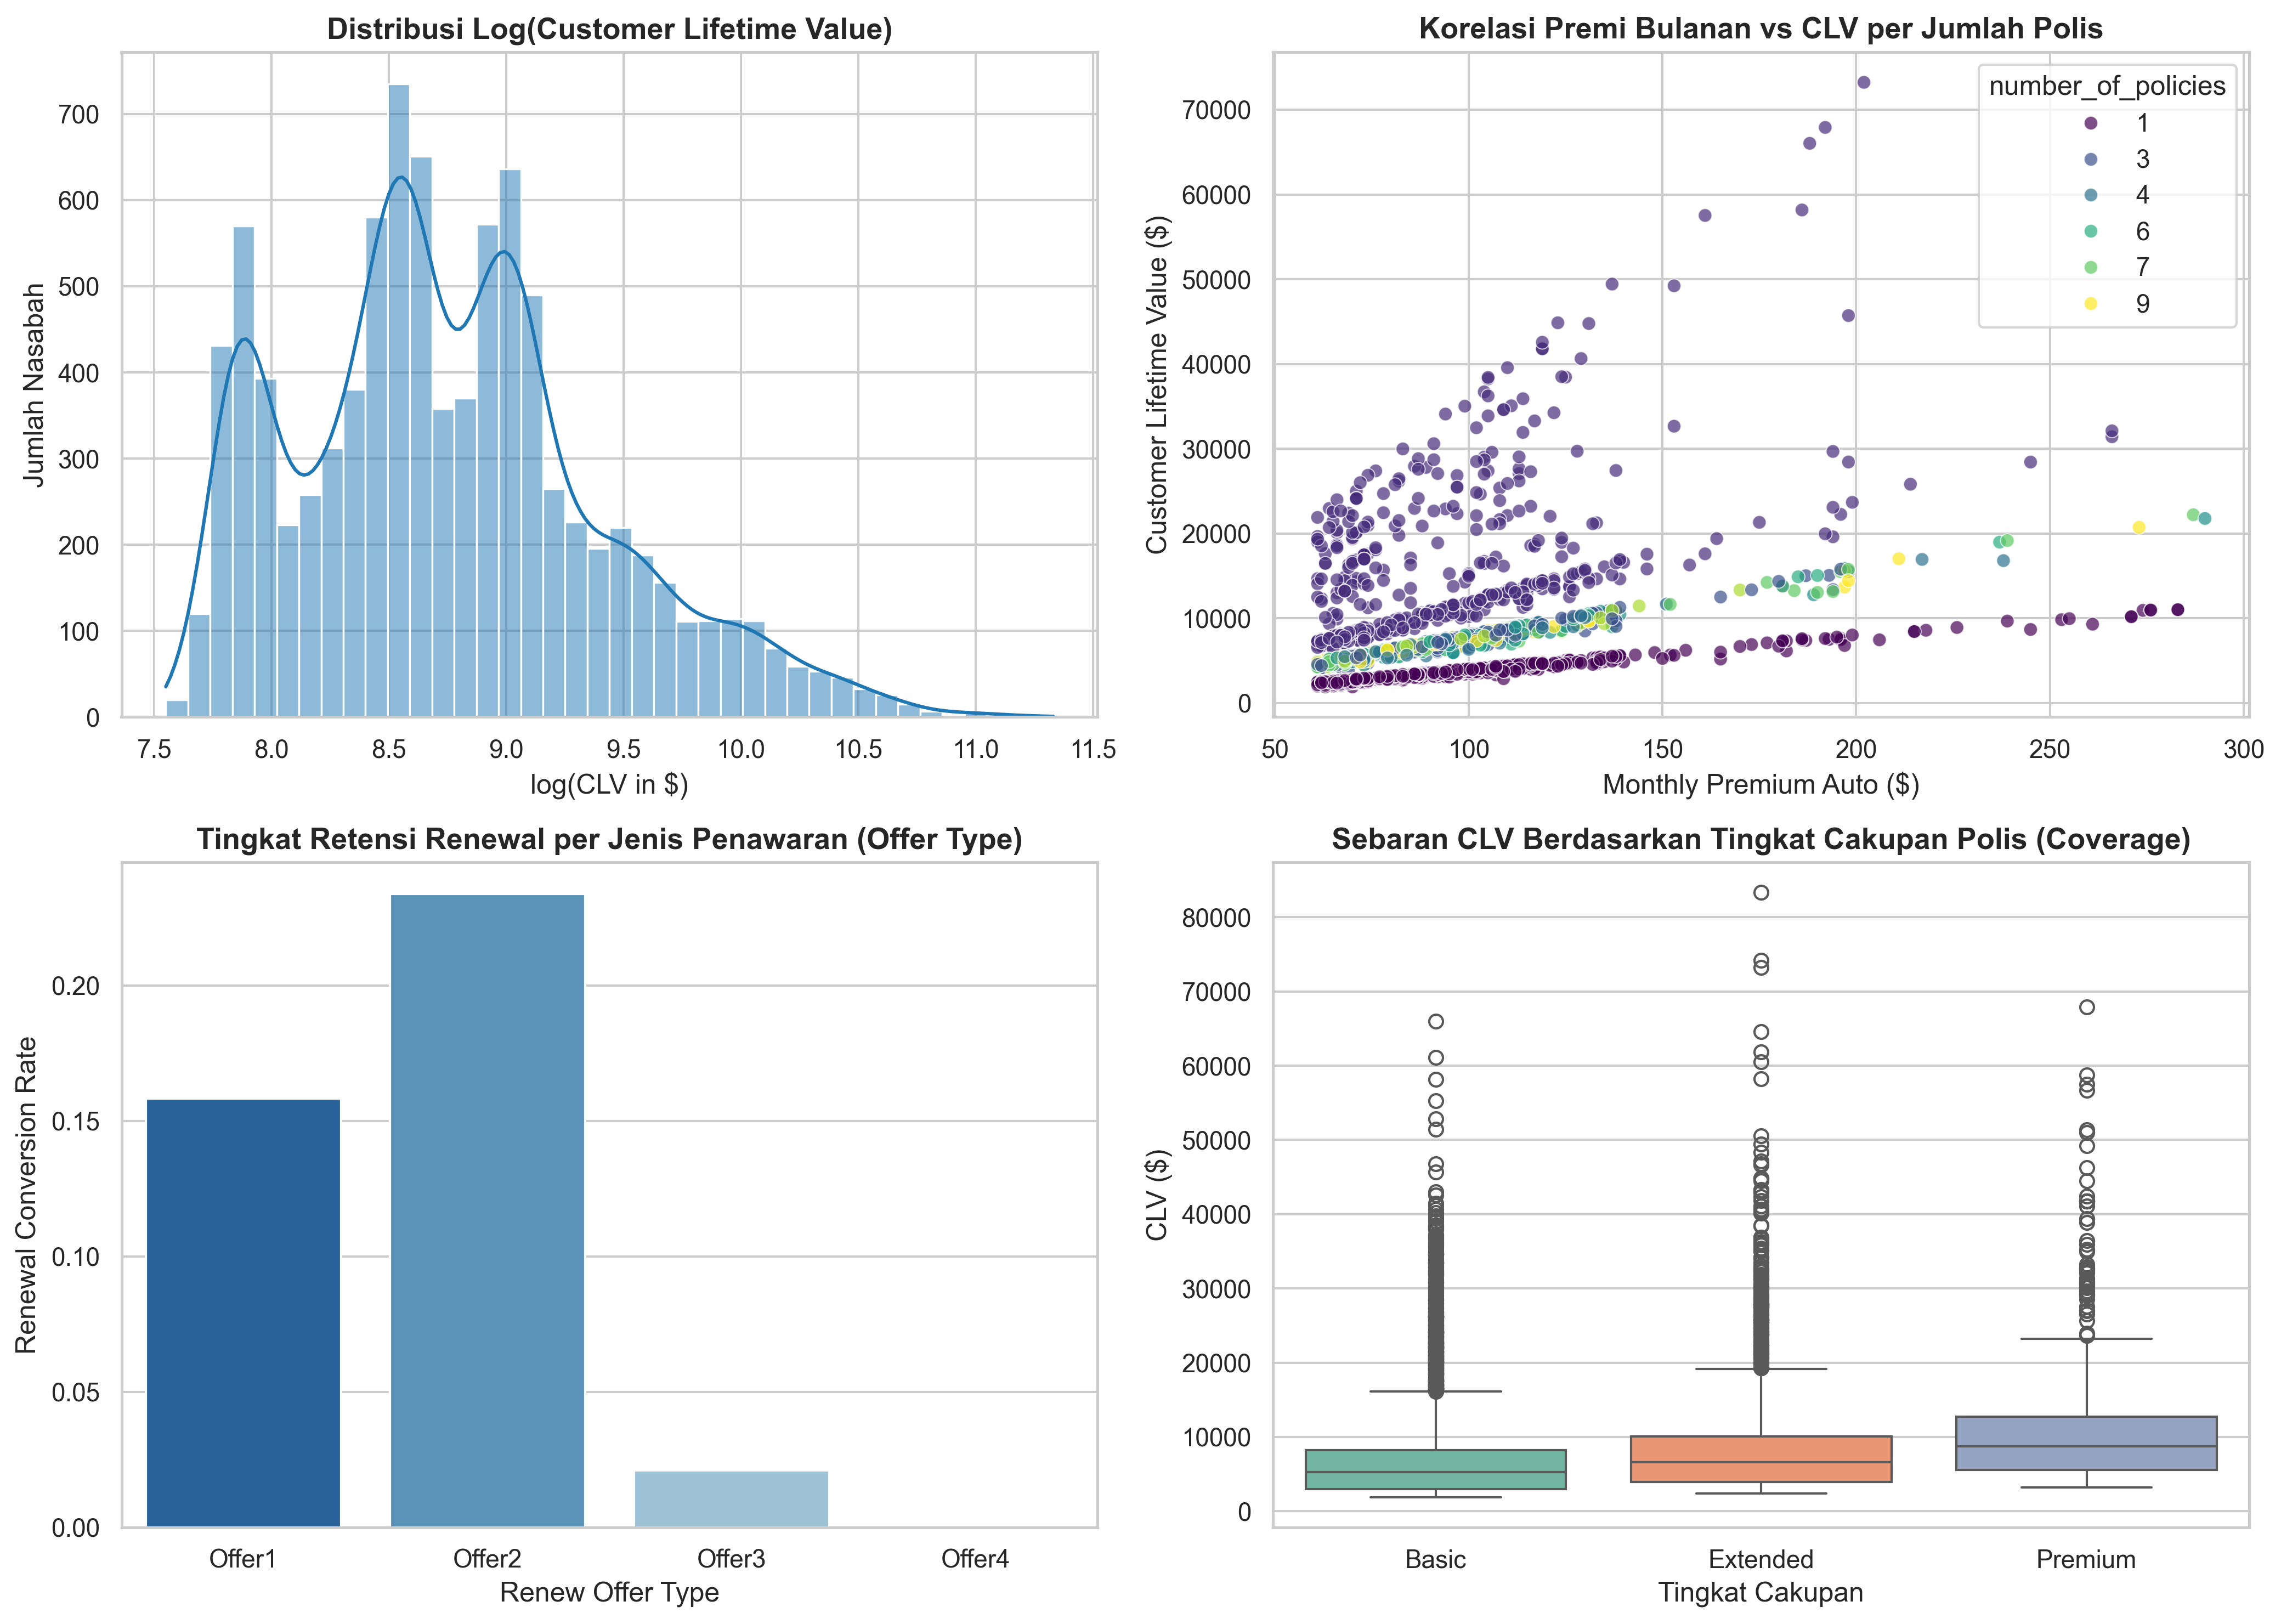

Visualisasi EDA CLV & Retensi berhasil diekspor ke images/clv_retention_eda.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribusi Log Target Customer Lifetime Value (CLV)
sns.histplot(np.log1p(df['customer_lifetime_value']), bins=40, kde=True, color='#1f77b4', ax=axes[0, 0])
axes[0, 0].set_title('Distribusi Log(Customer Lifetime Value)', fontweight='bold')
axes[0, 0].set_xlabel('log(CLV in $)')
axes[0, 0].set_ylabel('Jumlah Nasabah')

# 2. Hubungan CLV vs Premi Bulanan (Monthly Premium Auto) Berdasarkan Jumlah Polis
sns.scatterplot(data=df.sample(2000, random_state=42), x='monthly_premium_auto', y='customer_lifetime_value', hue='number_of_policies', palette='viridis', alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title('Korelasi Premi Bulanan vs CLV per Jumlah Polis', fontweight='bold')
axes[0, 1].set_xlabel('Monthly Premium Auto ($)')
axes[0, 1].set_ylabel('Customer Lifetime Value ($)')

# 3. Efektivitas Penawaran Renewal (Renew Offer Type) terhadap Tingkat Respons
renewal_resp = df.groupby('renew_offer_type')['response'].apply(lambda s: (s == 'Yes').mean()).reset_index()
sns.barplot(data=renewal_resp, x='renew_offer_type', y='response', palette='Blues_r', ax=axes[1, 0])
axes[1, 0].set_title('Tingkat Retensi Renewal per Jenis Penawaran (Offer Type)', fontweight='bold')
axes[1, 0].set_xlabel('Renew Offer Type')
axes[1, 0].set_ylabel('Renewal Conversion Rate')

# 4. Tingkat CLV Berdasarkan Cakupan Polis (Coverage)
sns.boxplot(data=df, x='coverage', y='customer_lifetime_value', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Sebaran CLV Berdasarkan Tingkat Cakupan Polis (Coverage)', fontweight='bold')
axes[1, 1].set_xlabel('Tingkat Cakupan')
axes[1, 1].set_ylabel('CLV ($)')

plt.tight_layout()
plt.savefig('images/clv_retention_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi EDA CLV & Retensi berhasil diekspor ke images/clv_retention_eda.png")

In [4]:
# Preprocessing & Feature Engineering Terisolasi
drop_cols = ['customer', 'effective_to_date', 'customer_lifetime_value']
X = df.drop(columns=drop_cols).copy()
# Target log-transformed untuk stabilisasi varians distribusi heavy-tailed
y_raw = df['customer_lifetime_value'].values
y_log = np.log1p(y_raw)

# Identifikasi kolom numerik dan kategorikal
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Holdout Split Terisolasi (80% Train, 20% Test)
X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=42
)

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[cat_cols])

X_train_enc = np.hstack([X_train[num_cols].values, ohe.transform(X_train[cat_cols])])
X_test_enc = np.hstack([X_test[num_cols].values, ohe.transform(X_test[cat_cols])])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

print(f"Ukuran sampel pelatihan: {X_train_scaled.shape[0]} baris x {X_train_scaled.shape[1]} fitur")
print(f"Ukuran sampel pengujian: {X_test_scaled.shape[0]} baris x {X_test_scaled.shape[1]} fitur")

Ukuran sampel pelatihan: 7307 baris x 50 fitur
Ukuran sampel pengujian: 1827 baris x 50 fitur


In [5]:
# Model Training & Baseline Comparison (CLV Regression)

# 1. Baseline: Ridge Regression
model_ridge = Ridge(alpha=1.0, random_state=42)
model_ridge.fit(X_train_scaled, y_train_log)
pred_ridge_log = model_ridge.predict(X_test_scaled)
pred_ridge = np.expm1(pred_ridge_log)

# 2. Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
model_rf.fit(X_train_scaled, y_train_log)
pred_rf_log = model_rf.predict(X_test_scaled)
pred_rf = np.expm1(pred_rf_log)

# 3. LightGBM Regressor
model_lgb = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
model_lgb.fit(X_train_scaled, y_train_log)
pred_lgb_log = model_lgb.predict(X_test_scaled)
pred_lgb = np.expm1(pred_lgb_log)

print("Pelatihan model regresi CLV selesai dieksekusi.")

Pelatihan model regresi CLV selesai dieksekusi.


=== EVALUASI PERFORMA MODEL PREDIKSI CLV ===
Ridge Baseline       - R2: 0.0952 | RMSE: $6,828.67 | MAE: $3,668.06
Random Forest        - R2: 0.6784 | RMSE: $4,071.37 | MAE: $1,409.60
LightGBM Regressor   - R2: 0.6742 | RMSE: $4,097.58 | MAE: $1,432.31


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9100\4176396098.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Blues_r', ax=axes[1])


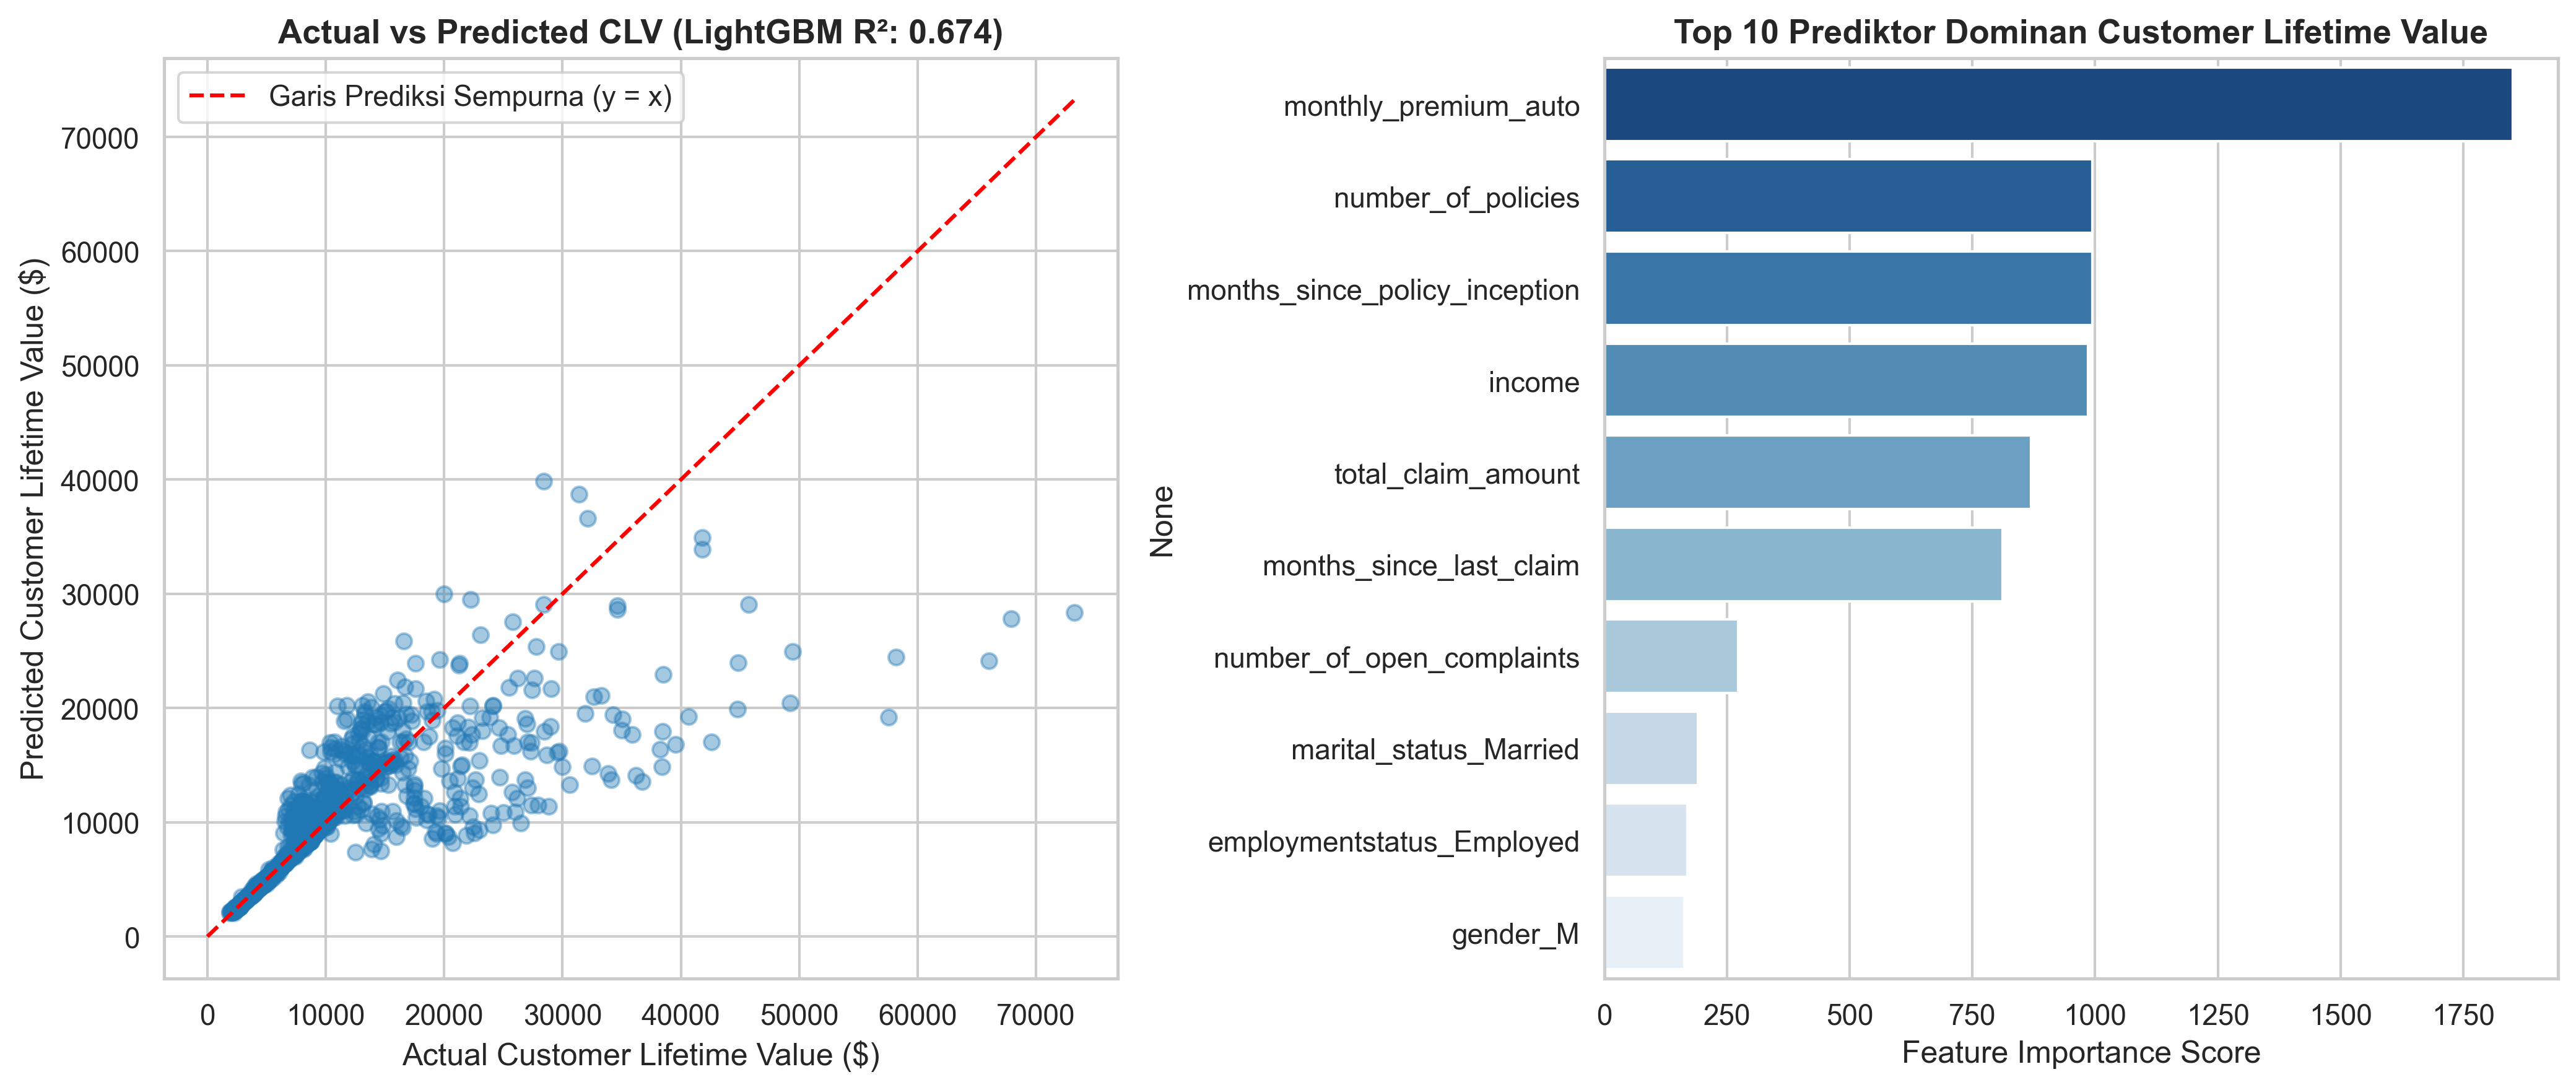

Visualisasi evaluasi model CLV berhasil diekspor ke images/clv_model_evaluation.png


In [6]:
# Evaluasi Kuantitatif Metrik Regresi (Skala Dolar Aktual)
def evaluate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

r2_ridge, rmse_ridge, mae_ridge = evaluate_metrics(y_test_raw, pred_ridge)
r2_rf, rmse_rf, mae_rf = evaluate_metrics(y_test_raw, pred_rf)
r2_lgb, rmse_lgb, mae_lgb = evaluate_metrics(y_test_raw, pred_lgb)

print("=== EVALUASI PERFORMA MODEL PREDIKSI CLV ===")
print(f"Ridge Baseline       - R2: {r2_ridge:.4f} | RMSE: ${rmse_ridge:,.2f} | MAE: ${mae_ridge:,.2f}")
print(f"Random Forest        - R2: {r2_rf:.4f} | RMSE: ${rmse_rf:,.2f} | MAE: ${mae_rf:,.2f}")
print(f"LightGBM Regressor   - R2: {r2_lgb:.4f} | RMSE: ${rmse_lgb:,.2f} | MAE: ${mae_lgb:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Actual vs Predicted CLV Plot
axes[0].scatter(y_test_raw, pred_lgb, alpha=0.4, color='#1f77b4')
max_val = max(y_test_raw.max(), pred_lgb.max())
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Garis Prediksi Sempurna (y = x)')
axes[0].set_title(f'Actual vs Predicted CLV (LightGBM R²: {r2_lgb:.3f})', fontweight='bold')
axes[0].set_xlabel('Actual Customer Lifetime Value ($)')
axes[0].set_ylabel('Predicted Customer Lifetime Value ($)')
axes[0].legend(loc='upper left')

# 2. Top 10 Feature Importance
feature_names = num_cols + ohe.get_feature_names_out(cat_cols).tolist()
importances = pd.Series(model_lgb.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)

sns.barplot(x=importances.values, y=importances.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 10 Prediktor Dominan Customer Lifetime Value', fontweight='bold')
axes[1].set_xlabel('Feature Importance Score')

plt.tight_layout()
plt.savefig('images/clv_model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi evaluasi model CLV berhasil diekspor ke images/clv_model_evaluation.png")